```
Author: Pranav S 
Trajectory Planning of 2R Manipulator 
```

In [32]:
#Import the necessary libraries
import sympy as sm
import sympy.physics.mechanics as me
me.init_vprinting(use_latex='mathjax')
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sympy import ImmutableDenseMatrix
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as litt
litt.rcParams['animation.embed_limit'] = 50.0

In [33]:
# Define the Reference Frames and Initialize the Variables
A=me.ReferenceFrame("A")
B=me.ReferenceFrame("B")
N=me.ReferenceFrame("N")
q1, q2=me.dynamicsymbols("q_1, q_2")
l1, l2,t, v=sm.symbols("l_1, l_2, t, v")

In [34]:
# Define the Matrices and points
qm=sm.Matrix([q1, q2])
s=sm.Matrix([l1, l2])
o=me.Point("O")
p1=me.Point("P_1")
p2=me.Point("P_2")
qd=sm.Matrix([q1.diff(), q2.diff()])

In [35]:
# Define the positions, time steps and Orientations
A.orient_axis(N, N.z, q1)
B.orient_axis(A, A.z, q2)
p1.set_pos(o, l1*A.x)
p2.set_pos(p1, l2*B.x)
fps=20
t_s=np.linspace(0, 5, 25*20)             #Time Steps

In [36]:
#Define the End Effector Positions
x_i, x_f, y=sm.symbols("x_i, x_f, y")
r_p1_o=p1.pos_from(o)
r_p2_p1=p2.pos_from(p1)
r_e=(x_i-(v*t))*N.x+y*N.y               #Velocity of End Effector is Constant
r_l=r_p1_o+r_p2_p1-r_e

#Setting the Position Loop Closure Matrix
r_m=sm.Matrix([r_l.dot(N.x), r_l.dot(N.y)])
r_m=r_m.xreplace({x_i:8, y:5})      #Starting Position set it to x=8m, y=5  (ref. link lengths from IK P2P)
r_m

⎡l₁⋅cos(q₁) + l₂⋅(-sin(q₁)⋅sin(q₂) + cos(q₁)⋅cos(q₂)) + t⋅v - 8⎤
⎢                                                              ⎥
⎣   l₁⋅sin(q₁) + l₂⋅(sin(q₁)⋅cos(q₂) + sin(q₂)⋅cos(q₁)) - 5    ⎦

# Degrees of Freedom 

Now, in a normal 2R manipulator, DOF=2. Its obvious. However, in this case, when we constrain our 2R Manipulator's end Effector to move along a specific direction (here along -ve x-axis), we introduce **1 non-holonomic constraint**. Which is: 
$$
\vec{v}_e^N.\hat{n}_y=0
$$  
Hence the DOF of the mechanism **Reduces to 1**. Hence for our control/generalized speeds to be solved for, we introduce $\dot{q_1}$ as our independent variable. This also means, the **end effector's velocity magnitude CANNOT** be of our choice. Only the motion path is under our control.  
An alternate way of addressing is, I can set my $\vec{v}_e^N$. But that would mean, $\dot{q}_1$ and $\dot{q}_2$ now are **DEPENDANT** on $\vec{v}_e^N$. So, here we choose the 2nd choice of fixing, Ve. Hence we formulate this for our robotic system. 

In [37]:
# Initialize the Velocity Kinematics 
# Produce the velocity of P2 from the original loop

v_p2_N=p2.pos_from(o).dt(N).express(N)
v_e_N=r_e.dt(N)
v_l_N=v_p2_N-v_e_N

v_m=sm.simplify(sm.Matrix([v_l_N.dot(N.x), v_l_N.dot(N.y)]))


#Alternatively 
v_m_a=sm.simplify(r_m.diff(t))
if v_m_a==v_m:
    print("True")       #Returns true
v_m

True


⎡-l₁⋅sin(q₁)⋅q₁̇ - l₂⋅(q₁̇ + q₂̇)⋅sin(q₁ + q₂) + v⎤
⎢                                              ⎥
⎣  l₁⋅cos(q₁)⋅q₁̇ + l₂⋅(q₁̇ + q₂̇)⋅cos(q₁ + q₂)   ⎦

# Expressing Dependant Speeds

Its obvious that for the system of Equations we have formulated, we have to express $\dot{q}_2$, $\dot{q}_1$ in terms of $v$. To achieve that, we can say: 
$$
V_m=J_k*[\dot{q}_1 \quad \dot{q}_2]^T+g_k=0
$$
Where: 
- $V_m$: Velocity Matrix Obtained 
- $J_k$: Jacobian of $V_m$ w.r.t $\dot{q}_2$ and $\dot{q}_1$.  
 
To obtain $g_k$, its obvious if we substitute $\dot{q}_2=0$ (on both sides), we'll obtain $g_k$. And thus by inverting this system (by consider only $g_k$, $J_k$), we can express $\dot{q}_2$ in terms of $\dot{q}_1$. 

>[NOTE] 
>HOWEVER, its not possible to do that, as Sympy and no programming language would treat a derivative as a linear variable. To reduce that complexity, we have to map, these differential variables to a separate set of **LINEARIZED** variables. 

This is primarily due to the fact that the above equations are a type of **Differential Algebraic Equations (DAE)**. Hence, to do that, we add a key-value mapping as done below. 

In [38]:
#Create key-value mapping with q2d and q1d. 
u1, u2=me.dynamicsymbols("u_1, u_2")            #Linearized Random Variables
d={q1.diff():u1, q2.diff():u2}                  #Set the Key-Value Mapping 
v_m=v_m.xreplace(d)
# Express the Generalized Speeds 
Jk=sm.simplify(v_m.jacobian(sm.Matrix([u1, u2])))
gk=v_m.xreplace({u1:0, u2:0})
Jk, gk

⎛⎡-l₁⋅sin(q₁) - l₂⋅sin(q₁ + q₂)  -l₂⋅sin(q₁ + q₂)⎤  ⎡v⎤⎞
⎜⎢                                               ⎥, ⎢ ⎥⎟
⎝⎣l₁⋅cos(q₁) + l₂⋅cos(q₁ + q₂)   l₂⋅cos(q₁ + q₂) ⎦  ⎣0⎦⎠

In [39]:
# To confirm all Differential variables have been replaced, we can use

me.find_dynamicsymbols(gk)          #Will return the respective variables (Linearized)

set()

In [40]:
#Inverting the Equation
sol=-Jk.LUsolve(gk)
d[q1.diff()]=sol[0]
d[q2.diff()]=sol[1]
me.find_dynamicsymbols(sol), d     #Will only return q1, q2

⎛          ⎧     ⎛                           l₂⋅v⋅(l₁⋅cos(q₁) + l₂⋅cos(q₁ + q₂ ↪
⎜          ⎪    -⎜- ────────────────────────────────────────────────────────── ↪
⎜          ⎪     ⎜                                  ⎛                  l₂⋅(l₁⋅ ↪
⎜          ⎪     ⎜  (-l₁⋅sin(q₁) - l₂⋅sin(q₁ + q₂))⋅⎜l₂⋅cos(q₁ + q₂) + ─────── ↪
⎜          ⎨     ⎝                                  ⎝                          ↪
⎜{q₁, q₂}, ⎪q₁̇: ────────────────────────────────────────────────────────────── ↪
⎜          ⎪                                           -l₁⋅sin(q₁) - l₂⋅sin(q₁ ↪
⎜          ⎪                                                                   ↪
⎝          ⎩                                                                   ↪

↪ ))⋅sin(q₁ + q₂)                             ⎞                                ↪
↪ ──────────────────────────────────────── + v⎟                                ↪
↪ cos(q₁) + l₂⋅cos(q₁ + q₂))⋅sin(q₁ + q₂)⎞    ⎟                                ↪
↪ ────────────────────────

In [41]:
v_m2=sm.Matrix([v])
t2=sm.Matrix([t])
sub=sm.lambdify((qm, s, v_m2), [Jk, gk], modules="numpy")     #Converts the Sympy object to a numpy array. Returns Jk, gk for inputs qm, s. 
v_e=np.array([2])                     #Set v_e=2ms^-1
l_s=sm.lambdify((qm, s, v_m2, t2), r_m)

In [42]:
#Initial Guess Values and solution for t=0. 
l=np.array([10, 10])        #Link lengths for l1, l2
q_g0=np.deg2rad(np.array([95, -124]))
def root(qm, s, v_m2, t2): 
    res=np.squeeze(l_s(qm, s, v_m2, t2))               
    return res
sol2=sp.optimize.fsolve(root, q_g0, args=(l, v_e, np.array([0])))
sol2

array([ 1.63817896, -2.15915929])

In [43]:
def solv(t, qm, l, v_m2): 
    # Find the angles of q1, q2 from v
    q_i=sp.optimize.root(root, qm, args=(l, v_m2, np.array([t])), method='lm')
    q_i=q_i.x
    Jk_s, gk_s=(sub(q_i, l, v_m2))
    qd1=np.squeeze(np.linalg.solve(np.array(Jk_s), -np.array(gk_s)))
    print(q_i)
    return qd1
solution=sp.integrate.solve_ivp(solv, (0, 5), q_g0, args=(l, v_e), t_eval=t_s, rtol=1e-8, atol=1e-7)

[ 1.63817896 -2.15915929]
[ 1.65820744 -2.17740324]
[ 1.6391227  -2.16002926]
[ 1.63959479 -2.16046406]
[ 1.64195746 -2.16263628]
[ 1.64237788 -2.16302214]
[ 1.64290357 -2.16350433]
[ 1.64290357 -2.16350433]
[ 1.65239768 -2.17215839]
[ 1.65716761 -2.17646735]
[ 1.6812546  -2.19783044]
[ 1.68557946 -2.20159642]
[ 1.69100426 -2.20629025]
[ 1.69100426 -2.20629025]
[ 1.74636305 -2.25230055]
[ 1.77493199 -2.27471667]
[ 1.92845251 -2.38040178]
[ 1.95789475 -2.39797085]
[ 1.99573856 -2.41935789]
[ 1.99573856 -2.41935789]
[ 1.73247218 -2.24107673]
[ 1.75369577 -2.25813943]
[ 1.86544741 -2.33995841]
[ 1.88641526 -2.35385756]
[ 1.91314563 -2.37093769]
[ 1.91314563 -2.37093769]
[ 1.96280592 -2.40082145]
[ 1.98842516 -2.41532761]
[ 2.12524058 -2.48301789]
[ 2.15119862 -2.49412245]
[ 2.1843819  -2.50756734]
[ 2.1843819  -2.50756734]
[ 1.95052881 -2.39365282]
[ 1.96966468 -2.40476468]
[ 2.07015235 -2.4576698 ]
[ 2.08890861 -2.46657853]
[ 2.11275379 -2.47748761]
[ 2.11275379 -2.47748761]
[ 2.15682427

In [44]:
#Convert the angles by restricting between [0,2pi] in degs
q_a=np.transpose(solution.y)        #Extract the angles
q_a

array([[ 1.65806279, -2.16420827],
       [ 1.66015372, -2.16613437],
       [ 1.66224755, -2.16805813],
       [ 1.66434429, -2.16997952],
       [ 1.66644398, -2.17189856],
       [ 1.66854661, -2.17381525],
       [ 1.67065222, -2.17572957],
       [ 1.67276082, -2.17764153],
       [ 1.67487243, -2.17955113],
       [ 1.67698707, -2.18145836],
       [ 1.67910476, -2.18336322],
       [ 1.68122551, -2.18526571],
       [ 1.68334935, -2.18716583],
       [ 1.68547629, -2.18906356],
       [ 1.68760635, -2.19095892],
       [ 1.68973955, -2.1928519 ],
       [ 1.69187592, -2.19474249],
       [ 1.69401546, -2.19663069],
       [ 1.6961582 , -2.1985165 ],
       [ 1.69830416, -2.20039992],
       [ 1.70045336, -2.20228094],
       [ 1.70260582, -2.20415956],
       [ 1.70476155, -2.20603578],
       [ 1.70692058, -2.20790959],
       [ 1.70908292, -2.209781  ],
       [ 1.7112486 , -2.21164998],
       [ 1.71341763, -2.21351655],
       [ 1.71559004, -2.2153807 ],
       [ 1.71776584,

In [45]:
#Formulate the Expressions for q1d, q2d. 
q1d2=sm.Matrix([d[q1.diff()], d[q2.diff()]])        #Dict d contains values of q1d, q2d in terms of q1, q2 and v and link lengths
e_ang_vel=sm.lambdify([qm, s, v_m2], q1d2)
def calc_ang_vel(qm, s, v_m2): 
    qd_res=[]
    for i in qm: 
        q1_r, q2_r=e_ang_vel(i, s, v_m2)
        qd_res+=[[q1_r, q2_r],]
    qd_res=np.rad2deg(np.array(qd_res))
    return qd_res
qd_res=calc_ang_vel(q_a, l, v_e)
q1r=qd_res[:, 0]
q2r=qd_res[:, 1]
q1r

array([[12.08920308],
       [12.10605776],
       [12.12301697],
       [12.14008111],
       [12.15725056],
       [12.1745257 ],
       [12.19190692],
       [12.2093946 ],
       [12.22698913],
       [12.24469091],
       [12.26250031],
       [12.28041773],
       [12.29844357],
       [12.31657822],
       [12.33482207],
       [12.35317552],
       [12.37163897],
       [12.39021281],
       [12.40889745],
       [12.42769328],
       [12.44660071],
       [12.46562014],
       [12.48475197],
       [12.50399661],
       [12.52335445],
       [12.54282592],
       [12.56241139],
       [12.58211127],
       [12.60192597],
       [12.6218559 ],
       [12.64190147],
       [12.66206309],
       [12.68234118],
       [12.70273614],
       [12.72324839],
       [12.74387833],
       [12.7646264 ],
       [12.78549298],
       [12.80647851],
       [12.82758338],
       [12.84880803],
       [12.87015285],
       [12.89161826],
       [12.91320468],
       [12.93491251],
       [12

In [46]:
q1d2                    #Matrix formed with q1d and q2d
qdd=q1d2.diff(t)         #Formulation of Angular Acceleration
qdd=qdd.xreplace(d)
e_ang_acc=sm.lambdify([qm, s, v_m2], qdd)
def ang_accel(qm, s, v_e): 
    ls=[]
    for i in qm: 
        ls+=[e_ang_acc(i, s, v_e)]
    ls=np.array(ls)
    return ls
accel=ang_accel(q_a, l, v_e)
q1dd=accel[:, 0]
q2dd=accel[:, 1]

In [ ]:
q1d2                    #Matrix formed with q1d and q2d
qdd=q1d2.diff(t)         #Formulation of Angular Acceleration
qdd=qdd.xreplace(d)
e_ang_acc=sm.lambdify([qm, s, v_m2], qdd)
def ang_accel(qm, s, v_e): 
    ls=[]
    for i in qm: 
        ls+=[e_ang_acc(i, s, v_e)]
    ls=np.array(ls)
    return ls
accel=ang_accel(q_a, l, v_e)
q1dd=accel[:, 0]
q2dd=accel[:, 1]

# Methods of Dynamics 

So, in our model so far we've analyzed on the IK which ineherently solves for $q_1$ and $q_2$ from $\dot{q}_1$ and $\dot{q}_2$. As an IVP. In any robot for control using some technique (like PID/LQR), we have to know about the **Actuation torques** required to correct the robot for the specified target Torques. Usually a Newton-Eulerian Approach is chosen for analyzing the Dynamics. But here we analyze the Dynamics using Kane's Equations and methods.  

To start the analysis, first lets characterize all the External (Explict) forces acting on the body. For this we should use a FBD on the whole 2R manipulator. Aside of the internal forces and torques, the only external forces are: Gravitational force experienced by the 2 links. 

**Note**: A force is experienced by the End Effector only when it hits an obstacle. In other cases it doesnt experience any force. 

In [10]:
# Define the forces 
m, g=sm.symbols("m,g")
w_1g=-m*g*N.y
w_2g=-m*g*N.y

# Concept of Partial Velocities 

The rth partial velocity of a point in space w.r.t another FOR "N" is defined as: 
$$
\vec{v}_{P,r}^N= \frac{\partial \vec{v}_P^N}{\partial u_r}
$$
where: $u_r$ is the **Independent Speed** chosen. In our case, the only Independent (or the Generalized speed) chosen is $v_e$ (which is the velocity of the end effector) as DOF of mechanism=1. Hence, we first tend to replace the required variables in velocity and then partially differentiate w.r.t $v_e$. Here, the points of interest are the **COM** (Center of masses) of the links (which is at the center of the links). (Ref Kane's Equations for why we consider COM)  

Similarily the rth active partial angular velocity of a point in a RF "P" w.r.t another FOR "N" is given by: 
$$
\vec{\omega}_{P}^N= \frac{\partial \vec{\omega}_P^N}{\partial u_r}
$$

In [26]:
#Define the Center of masses
p1o=me.Point("P1_O")
p2o=me.Point("P2_O")
p1o.set_pos(o, (l1/2)*A.x)
p2o.set_pos(p1o, (l2/2)*B.x)
o.set_vel(N, 0)
v_p1o_N=p1o.vel(N)
v_p2o_N=p2o.vel(N)      #Vel of COMs w.r.t N
v_p1o_N, v_p2o_N

⎛l₁⋅q₁̇      l₂⋅(q₁̇ + q₂̇)       l₁⋅q₁̇    ⎞
⎜───── a_y, ──────────── b_y + ───── a_y⎟
⎝  2             2               2      ⎠

In [ ]:
#Replace the dependant variables 
v_p1o_N=v_p1o_N.xreplace(d)
v_p2o_N=v_p2o_N.xreplace(d)

## Generate the partial speeds 
ul1_1=v_p1o_N.diff(v, N)
ul2_1=v_p2o_N.diff(v, N)

# Setting the Kane's Equations for Newton's Equations

The Kane's Extension for the Resultant Force on the $i^{th}$ particle, defined for a region S containing $\nu$ particles is given by: 
$$
F_r=\sum_{r=1}^{\nu} \vec{v}_{P_i, r}^N \cdot\vec{R}_i
$$
where: 
- $\vec{R}_i$: Net Resultant Vector Force on the $i^{th}$ particle of the system 
- $\vec{v}_{P_i, r}$: Partial velocity of the $i^{th}$ particle relative to a FOR "N".  

$F_r$ is a scalar and not a vector. Its infact called a **Generalized Active Force** on the system. Furthermore the net resultant on the **Entire system** (S) of particles is given by: 
$$
F_{r, S}=\sum_{i=1}^{\nu} \sum_{r=1}^{\nu} \vec{v}_{P_i, r}^N \cdot\vec{R}_i
$$

Following D'Alembert's principles, similarily the Kane's Extension for the **Inertia Force** is given by: (Directly for a system of $\nu$ particles)
$$
F_{r, S}^*=-\sum_{i=1}^{\nu} \sum_{r=1}^{\nu} \vec{v}_{P_i, r}^N \cdot (m_i*\vec{a}_{P, i}^N)
$$
where:
- $\vec{a}_{P, i}^N$ is the acceleration of the $i^{th}$ particle relative to the FOR N. 
- $m_i$: Mass of the $i^{th}$ particle. 
By combining both, the Kane's Equations formulate to: 
$$
F_{r, S}+F_{r, S}^{*}=0
$$

## For a Rigid Body

For a rigid body the same equations reduce to: 
$$
F_r=\sum_{r=1}^{\nu} \vec{v}_{{CM}_i, r}^N \cdot\vec{R}_{CM}
$$
where: 
- $\vec{R}_{CM}$: Net Resultant Vector Force on the COM (Center of mass) of the rigid body. 
- $\vec{v}_{P_{CM}, r}$: Partial velocity of the COM relative to a FOR "N".  

For a system of $\nu$ Rigid Bodies (or Multi Bodies), the final expression of the Active Generalized forces boils down to:  

$$
F_{r, S}=\sum_{i=1}^{\nu} \sum_{r=1}^{\nu} \vec{v}_{CM_{i}, r}^N \cdot\vec{R}_{CM}
$$  

And further more, the resultant comes down to: 
$$
F_{r, S}^*=-\sum_{i=1}^{\nu} \sum_{r=1}^{\nu} \vec{v}_{CM_{i}, r}^N \cdot (m_i*\vec{a}_{, i, CM}^N)
$$
And the same Kane's equation holds good. In all the above equations, "N" is supposed to be a **Fixed Frame of Reference** (as Newton's Equations are applicable for translations relative to a fixed FOR). And hence all partial velocities have to be w.r.t this fixed FOR. 

# Setting the Kane's Equations for Euler's Equations 

Euler's Equations are used to account for the effects of Torques on the System of rigid bodies (or particles). 

## For a System of Particles 
The Kane's Extension for the Resultant **Torques** on the $i^{th}$ particle, defined for a region S containing $\nu$ particles is given by: 
$$
T_r=\sum_{r=1}^{\nu} \vec{\omega}_{P_i, r}^N \cdot\vec{T}_{i,O}
$$
where: 
- $\vec{T}_i$: Net Resultant Vector Torque on the $i^{th}$ particle of the system about a point O in RF "N"
- $\vec{\omega}_{P_i, r}$: Partial velocity of the $i^{th}$ particle relative to a FOR "N".  

$T_r$ is a scalar and not a vector. Its infact called a **Generalized Active Torque** on the system. Furthermore the net resultant on the **Entire system** (S) of particles is given by: 
$$
T_{r, S}=\sum_{i=1}^{\nu} \sum_{r=1}^{\nu} \vec{\omega}_{P_i, r}^N \cdot\vec{T}_i
$$

Following D'Alembert's principles, similarily the Kane's Extension for the **Generalized Inertia Torque** is given by: (Directly for a system of $\nu$ particles)
$$
T_{r, S}^*=-\sum_{i=1}^{\nu} \sum_{r=1}^{\nu} \vec{\omega}_{P_i, r}^N \cdot (m_i*(\vec{r}^{P_i/O} \times \vec{a}_{P, i}^N))
$$
where:
- $\vec{a}_{P, i}^N$ is the acceleration of the $i^{th}$ particle relative to the FOR N. 
- $\vec{r}^{\frac{P, i}{O}}$: Position vector of the $i^{th}$ point from the point O. 
- $m_i$: Mass of the $i^{th}$ particle. 
By combining both, the Kane's Equations formulate to: 
$$
T_{r, S}+T_{r, S}^{*}=0
$$


In [84]:
# Formulation of Generalized Angular velocities
ur=q1d2.diff(v)
ur_l1=ur[0]
ur_l2=ur[1]

# Define the torques at the joints
T1, T2=sm.symbols("T1, T2")

# Formulate the generalized active torques
Tr_l1=(ur_l1*A.z).dot((T1-T2)*A.z)
Tr_l2=(ur_l2*B.z).dot(T2*B.z)

#Formulate the Inertia Dyadic 
## Model the links as a rod 

I_l1=m*(l1**2)/12  
I_l2=m*(l2**2)/12
I_A_Ao=I_l1*((A.y.outer(A.y))+(A.z.outer(A.z)))
I_B_Bo=I_l2*((B.y.outer(B.y))+(B.z.outer(B.z)))
I_A_Ao.to_matrix(N), I_B_Bo.to_matrix(N)

⎛⎡      2      2              2                          ⎤  ⎡                  ↪
⎜⎢    l₁ ⋅m⋅sin (q₁)       -l₁ ⋅m⋅sin(q₁)⋅cos(q₁)        ⎥  ⎢                  ↪
⎜⎢    ──────────────       ───────────────────────    0  ⎥  ⎢                  ↪
⎜⎢          12                       12                  ⎥  ⎢                  ↪
⎜⎢                                                       ⎥  ⎢                  ↪
⎜⎢   2                           2      2                ⎥  ⎢  2               ↪
⎜⎢-l₁ ⋅m⋅sin(q₁)⋅cos(q₁)       l₁ ⋅m⋅cos (q₁)            ⎥  ⎢l₂ ⋅m⋅(-sin(q₁)⋅s ↪
⎜⎢───────────────────────      ──────────────         0  ⎥, ⎢───────────────── ↪
⎜⎢          12                       12                  ⎥  ⎢                  ↪
⎜⎢                                                       ⎥  ⎢                  ↪
⎜⎢                                                    2  ⎥  ⎢                  ↪
⎜⎢                                                  l₁ ⋅m⎥  ⎢                  ↪
⎜⎢           0              

In [85]:
#Formulation of the Generalized Inertia torques
IT_l1=-((ur_l1*A.z).dot(qdd[0]*A.z.dot(I_A_Ao)+(ur_l1*A.z).cross(I_A_Ao).dot((ur_l1*A.z))))
IT_l2=-((ur_l2*B.z).dot(qdd[1]*A.z.dot(I_B_Bo)+(ur_l2*B.z).cross(I_B_Bo).dot((ur_l2*B.z))))

# Formulation of Kane's Equations 
Kanes=sm.Matrix([[Tr_l1+IT_l1], [Tr_l2+IT_l2]])
m1=np.array([0.5])         #Set mass to 0.5kg
J_Kane=Kanes.jacobian([T1, T2])
g_Kane=Kanes.xreplace({T1:0, T2:0})
Torques=-J_Kane.LUsolve(g_Kane)
e_T=sm.lambdify([qm, s, sm.Matrix([m]), v_m2], Torques)
def Torques_solve(q_a, l, m1, v_e): 
    ls=[]
    for i in q_a: 
        ls+=[e_T(i, l, m1, v_e)]
    ls=np.array(ls)
    return ls
T_s=Torques_solve(q_a, l, m1, v_e)
T_s1=T_s[:, 0]
T_s2=T_s[:,1]


In [86]:
#Formulation of Jerk 
jerk=qdd.diff(t)
jerk=jerk.xreplace(d)
e_jerk=sm.lambdify([qm, s, v_m2], jerk)
def jerk(qm, s, v_e): 
    ls=[]
    for i in qm: 
        ls+=[e_jerk(i, s, v_e)]
    ls=np.array(ls)
    return ls
jerk=jerk(q_a, l, v_e)
q1j=jerk[:, 0]
q2j=jerk[:, 1]

(<Figure size 1500x1500 with 5 Axes>,
 array([<Axes: ylabel='Angles of the links in degs'>,
        <Axes: ylabel='Angular Velocities in deg/s'>,
        <Axes: ylabel='Ang. Acceleration in SI'>,
        <Axes: ylabel='Jerk of the links in SI'>,
        <Axes: xlabel='Time (t) in s', ylabel='Actuation Torque in N-m'>],
       dtype=object))

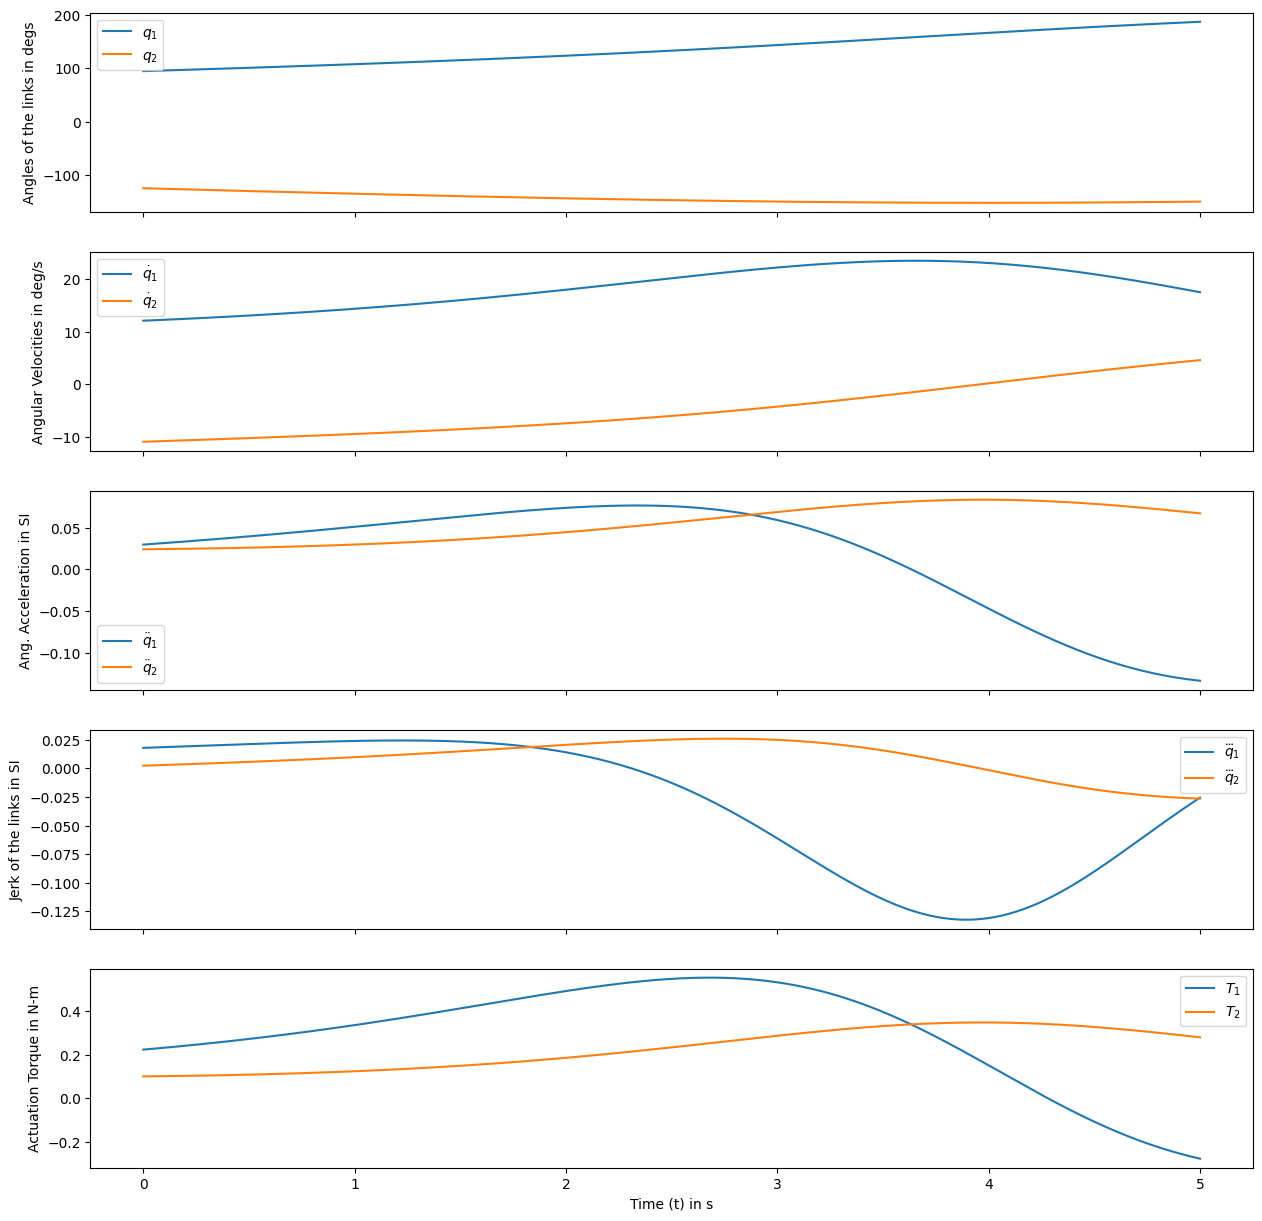

In [87]:
#Plot the various Mechanics quantities u
def qvst(q_a, qd, qdd, jerk, T_s, t_s): 
    fig, axes=plt.subplots(5,1, sharex=True)
    fig.set_size_inches(15, 15)
    axes[0].plot(t_s, np.rad2deg(q_a[:, 0]), label=r"$q_1$")
    axes[0].plot(t_s, np.rad2deg(q_a[:, 1]), label=r'$q_2$')
    axes[1].plot(t_s, qd[:,0], label=r'$\dot{q}_1$')
    axes[1].plot(t_s, qd[:,1], label=r'$\dot{q}_2$')
    axes[2].plot(t_s, qdd[:, 0], label=r'$\ddot{q}_1$')
    axes[2].plot(t_s, qdd[:, 1], label=r'$\ddot{q}_2$')
    axes[3].plot(t_s, jerk[:, 0], label=r'$\dddot{q}_1$')
    axes[3].plot(t_s, jerk[:, 1], label=r'$\dddot{q}_2$')
    axes[4].plot(t_s, T_s[:, 0], label=r'$T_1$')
    axes[4].plot(t_s, T_s[:, 1], label=r'$T_2$')
    axes[4].set_xlabel("Time (t) in s")
    axes[0].set_ylabel("Angles of the links in degs")
    axes[1].set_ylabel("Angular Velocities in deg/s")
    axes[2].set_ylabel("Ang. Acceleration in SI")
    axes[3].set_ylabel("Jerk of the links in SI")
    axes[4].set_ylabel("Actuation Torque in N-m")
    axes[0].legend()
    axes[1].legend()
    axes[2].legend()
    axes[3].legend()
    axes[4].legend()
    return fig, axes
qvst(q_a, qd_res, accel, jerk, T_s, t_s)